Imports + Paths

In [76]:
import os
import random
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
import numpy as np
import shutil

BASE_DIR = Path("data")

INPUT_DIR = BASE_DIR / "synthetic_clean" / "sdxl"
OUTPUT_DIR = BASE_DIR / "synthetic_degraded" / "sdxl"

CLASSES = ["clean", "empty", "finished_leftovers", "full", "unclassified"]

def reset_degraded_folder():
    if OUTPUT_DIR.exists():
        print("Deleting existing degraded folder...")
        shutil.rmtree(OUTPUT_DIR)

    # ליצור מחדש
    for cls in CLASSES:
        os.makedirs(OUTPUT_DIR / cls, exist_ok=True)

    print("Fresh degraded folder ready")

reset_degraded_folder()

Deleting existing degraded folder...
Fresh degraded folder ready


degradation function

In [77]:
# blur
def add_blur(img):
    return img.filter(ImageFilter.GaussianBlur(radius=random.uniform(1.5, 4.0)))

# noise
def add_noise(img):
    arr = np.array(img).astype(np.float32)

    noise = np.random.normal(0, random.uniform(15, 50), arr.shape)
    arr += noise

    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

# brightness / contrast
def change_lighting(img):
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.4, 1.8))

    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.4, 1.8))

    return img

# downscale
def downscale(img):
    size = random.choice([32, 48, 64, 96])
    small = img.resize((size, size))
    return small.resize((224, 224), Image.NEAREST)

# JPEG compression
def compress(img):
    temp_path = "temp.jpg"
    img.save(temp_path, quality=random.randint(5, 25))
    return Image.open(temp_path)

# color shift - cheap way to shift colors by manipulating the RGB channels
def color_shift(img):
    arr = np.array(img).astype(np.float32)

    arr[:, :, 0] *= random.uniform(0.8, 1.2)  # R
    arr[:, :, 1] *= random.uniform(0.8, 1.2)  # G
    arr[:, :, 2] *= random.uniform(0.8, 1.2)  # B

    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

# rotate - top view only
def rotate_image(img):
    angle = random.choice([0, 90, 180, 270])
    return img.rotate(angle, expand=True)

def slight_rotate(img):
    angle = random.uniform(-15, 15)
    return img.rotate(angle, resample=Image.BILINEAR, fillcolor=(0,0,0))


tilt / perspective

In [78]:
import random
import numpy as np
from PIL import Image
import cv2

def perspective_transform(img):
    width, height = img.size

    # distortion
    shift = random.uniform(0.05, 0.2) * width

    src = np.float32([
        [0, 0],
        [width, 0],
        [width, height],
        [0, height]
    ])

    dst = np.float32([
        [random.uniform(0, shift), random.uniform(0, shift)],
        [width - random.uniform(0, shift), random.uniform(0, shift)],
        [width - random.uniform(0, shift), height - random.uniform(0, shift)],
        [random.uniform(0, shift), height - random.uniform(0, shift)]
    ])

    matrix = cv2.getPerspectiveTransform(src, dst)

    # apply
    warped = cv2.warpPerspective(
        np.array(img),
        matrix,
        (width, height),
        borderMode=cv2.BORDER_REFLECT
    )

    return Image.fromarray(warped)

pipeline

In [79]:
def degrade_image(img, cls):

    # alywas
    img = downscale(img)

    if random.random() < 0.4:
        img = perspective_transform(img)

    if random.random() < 0.7:
        img = rotate_image(img)

    if random.random() < 0.9:
        img = add_blur(img)

    if random.random() < 0.9:
        img = add_noise(img)

    if random.random() < 0.8:
        img = change_lighting(img)

    if random.random() < 0.7:
        img = compress(img)

    if random.random() < 0.5:
        img = color_shift(img)
        

    # unclassified images are more degraded than others
    if cls == "unclassified":
        img = add_noise(img)
        img = add_blur(img)
        img = downscale(img)

    return img

loop

In [80]:
from tqdm import tqdm

total = 0

for cls in CLASSES:
    print(f"\nProcessing {cls}...")

    input_path = INPUT_DIR / cls
    output_path = OUTPUT_DIR / cls

    files = list(input_path.glob("*.jpg")) + list(input_path.glob("*.png"))

    for f in tqdm(files):
        img = Image.open(f).convert("RGB")

        degraded = degrade_image(img, cls)

        save_path = output_path / f.name
        degraded.save(save_path)

        total += 1

print("\nDone!")
print("Total processed:", total)


Processing clean...


100%|██████████| 20/20 [00:00<00:00, 25.34it/s]



Processing empty...


100%|██████████| 20/20 [00:00<00:00, 26.25it/s]



Processing finished_leftovers...


...


Processing full...


100%|██████████| 20/20 [00:00<00:00, 23.57it/s]



Processing unclassified...


100%|██████████| 20/20 [00:00<00:00, 26.70it/s]


Done!
Total processed: 100


visual checking

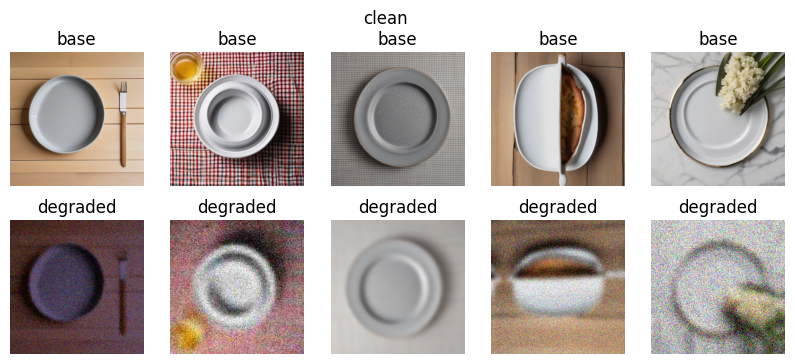

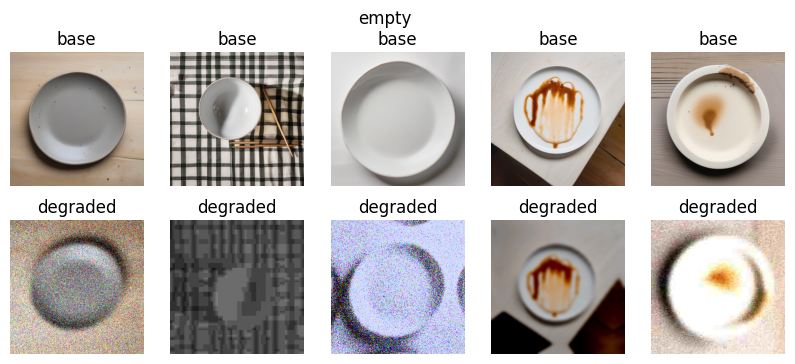

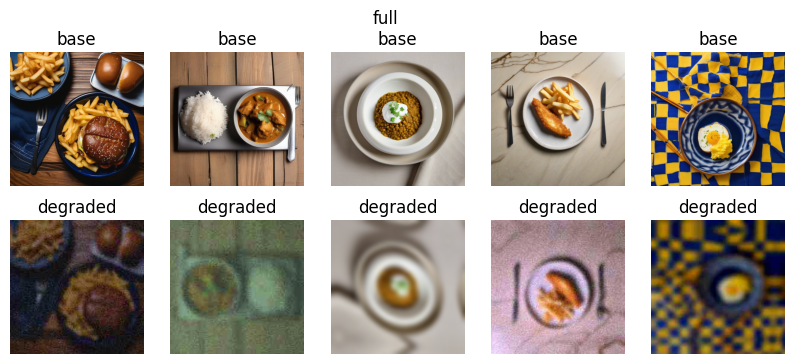

In [81]:
import matplotlib.pyplot as plt

def show_examples(cls):
    clean_files = list((INPUT_DIR / cls).glob("*"))[:5]
    degraded_files = list((OUTPUT_DIR / cls).glob("*"))[:5]

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))

    for i in range(5):
        axes[0, i].imshow(Image.open(clean_files[i]))
        axes[0, i].set_title("base")
        axes[0, i].axis("off")

        axes[1, i].imshow(Image.open(degraded_files[i]))
        axes[1, i].set_title("degraded")
        axes[1, i].axis("off")

    plt.suptitle(cls)
    plt.show()

def show_examples_multi(classes):
    for cls in classes:
        show_examples(cls)

show_examples_multi(classes=["clean", "empty", "full"])